In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

№1

In [ ]:
plt.figure(figsize=(6,6))
img_gray = cv2.imread('object.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(img_gray, cmap='gray')

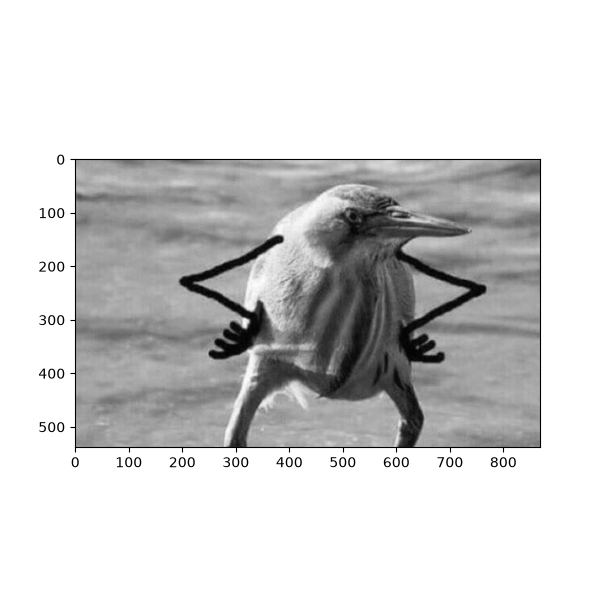

№2

In [ ]:
plt.figure(figsize=(15,6))
hist = cv2.calcHist([img_gray], [0], None, [256], (0, 256), accumulate=False)
plt.subplot(1,2,1)
plt.title('Histogram img_gray.jpg')
plt.plot(hist)

hist_cum = hist.cumsum()
plt.subplot(1,2,2)
plt.title('Сumulative Histogram img_gray.jpg')
plt.plot(hist_cum)

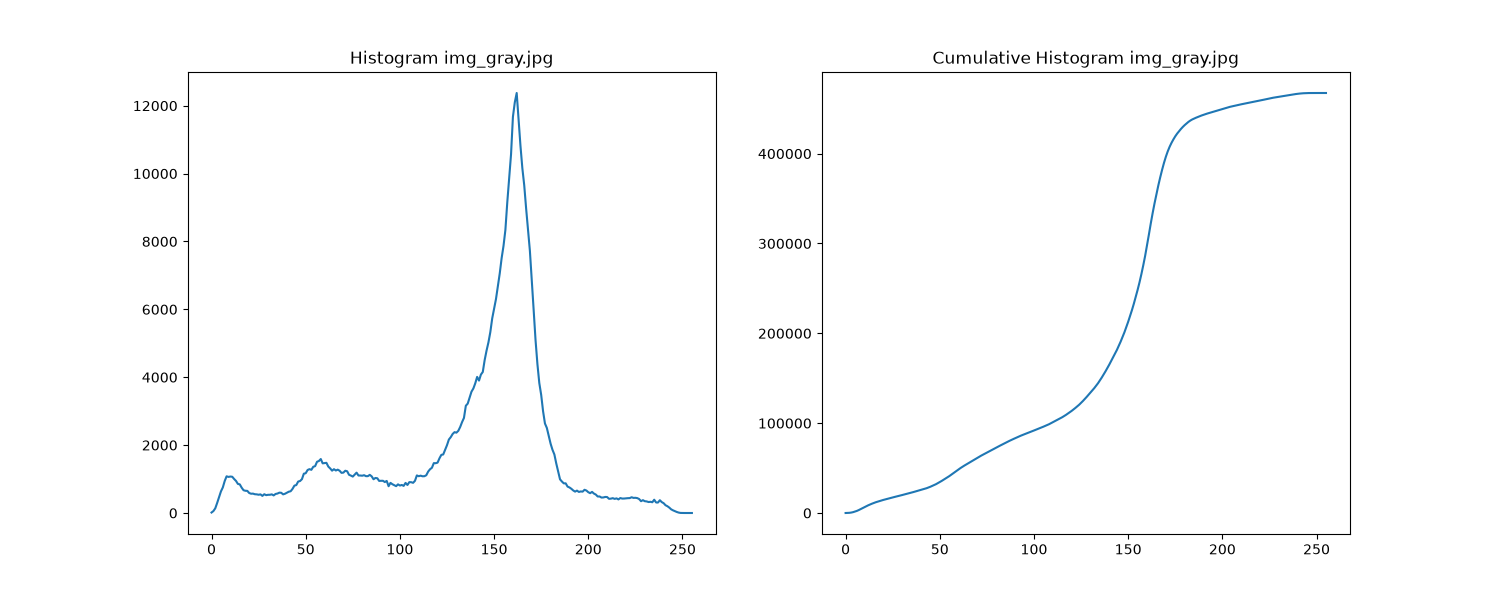

№3

In [ ]:
def gamma_correction(img, gamma=1.0):

    table = ((np.arange(256, dtype=np.float32) / 255.0) ** gamma * 255.0).astype(np.uint8)
    return cv2.LUT(img, table)

img_gamma_low  = gamma_correction(img_gray, gamma=0.5)
img_gamma_high = gamma_correction(img_gray, gamma=2.0)

plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_gamma_low, cmap='gray')
plt.title('Gamma <1')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_gamma_high, cmap='gray')
plt.title('Gamma >1')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_gray, cmap='gray')
plt.title('Orig')
plt.axis('off')

plt.show()

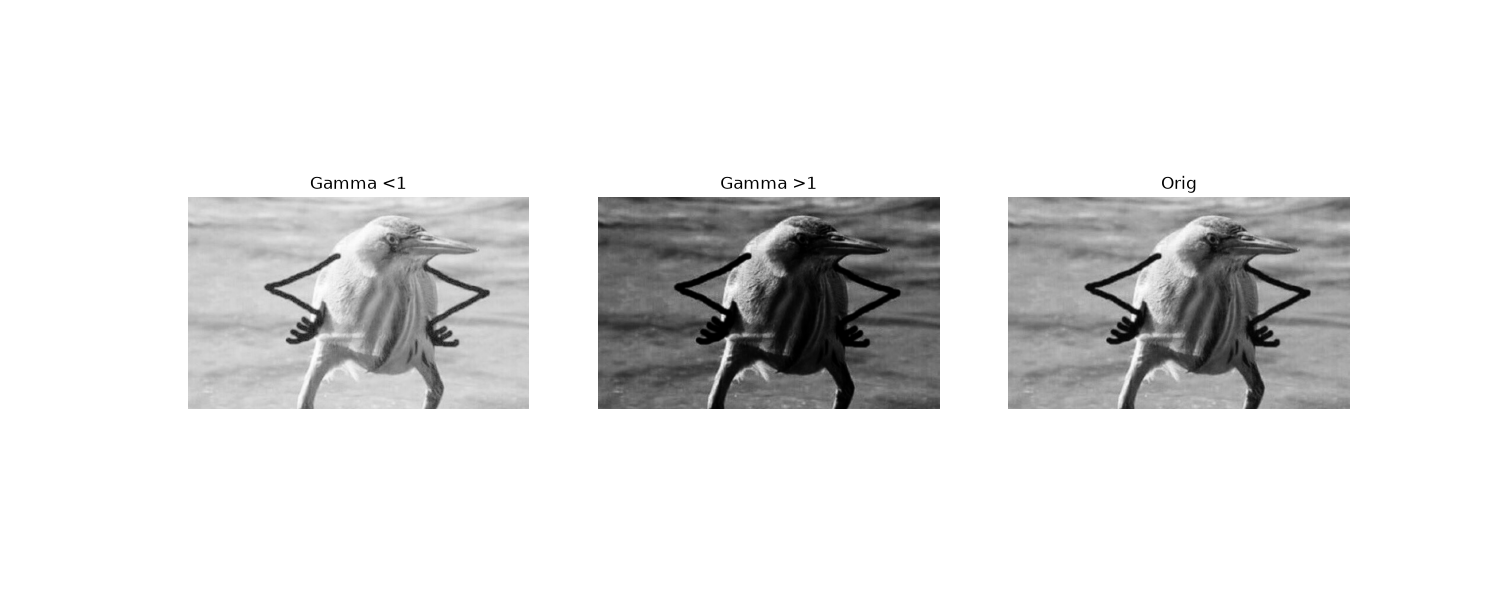

№4

In [ ]:
from skimage.metrics import structural_similarity, mean_squared_error

def gamma_correction(img_, gamma):
    return np.power(img_, gamma)

gamma_low  = 0.5
gamma_high = 2.0

img_gray_f = img_gray.astype('float32') / img_gray.max()

img_gamma_low_f  = gamma_correction(img_gray_f, gamma_low)
img_gamma_high_f = gamma_correction(img_gray_f, gamma_high)

img_gamma_low_8  = (img_gamma_low_f  * 255.).astype('uint8')
img_gamma_high_8 = (img_gamma_high_f * 255.).astype('uint8')


plt.figure(figsize=(10, 4))
plt.suptitle('Сравнение с скорректированными', fontsize=16)

# SSIM gamma < 1
(ssim_low, diff_low) = structural_similarity(img_gray_f, img_gamma_low_f, full=True, data_range=1.0)
diff_low = (diff_low * 255).astype('uint8')

print('Gamma < 1 (0.5)')
print('SSIM: {}'.format(ssim_low))

plt.subplot(1,2,1)
plt.title('Gamma < 1')
plt.imshow(diff_low, cmap='gray')
plt.axis('off')

# SSIM gamma > 1
(ssim_high, diff_high) = structural_similarity(img_gray_f, img_gamma_high_f, full=True, data_range=1.0)
diff_high = (diff_high * 255).astype('uint8')

print('Gamma > 1 (2)')
print('SSIM: {}'.format(ssim_high))

plt.subplot(1,2,2)
plt.title('Gamma > 1')
plt.imshow(diff_high, cmap='gray')
plt.axis('off')


# MSE
mse_low = mean_squared_error(img_gray_f, img_gamma_low_f)
mse_high = mean_squared_error(img_gray_f, img_gamma_high_f)

print('MSE low: {}'.format(mse_low))
print('MSE high: {}'.format(mse_high))

In [ ]:
Gamma < 1 (0.5)
SSIM: 0.9001998338314091
Gamma > 1 (2)
SSIM: 0.7880173229087569
MSE low: 0.03233001841225521
MSE high: 0.04714222523318209

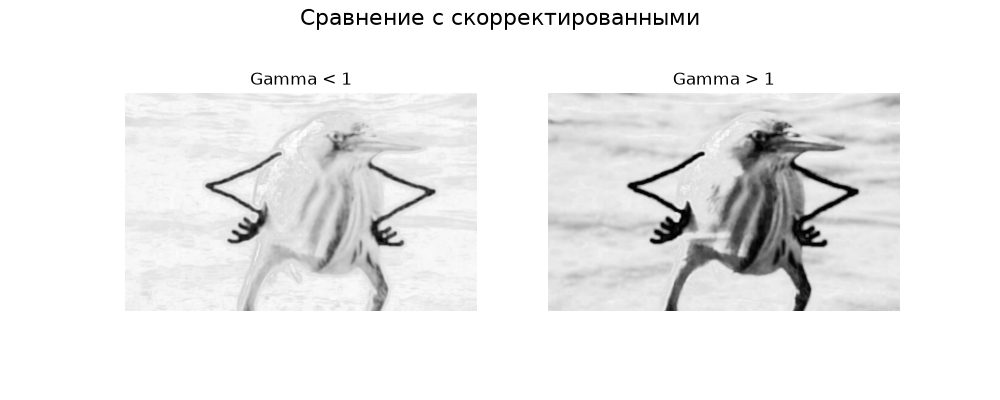

№5

In [ ]:
eq_gray = cv2.equalizeHist(img_gray.astype('uint8'))

src = img_gray.astype('float32')
src /= src.max()
eq = eq_gray.astype('float32')
eq /= eq.max()

mean_src = src.mean()
std_src = src.std()

mean_eq = eq.mean()
std_eq = eq.std()

img_corr = (std_eq / std_src) * (src - mean_src) + mean_eq
img_corr = np.clip(img_corr, 0, 1)
img_corr_8 = (img_corr * 255).astype('uint8')

plt.figure(figsize=(10, 4))
plt.suptitle('Статическая цветокоррекция', fontsize=16)

plt.subplot(1,2,1)
plt.title('Corrected')
plt.imshow(img_corr_8, cmap='gray')
plt.axis('off')
plt.subplot(1,2,2)
plt.title('Original')
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

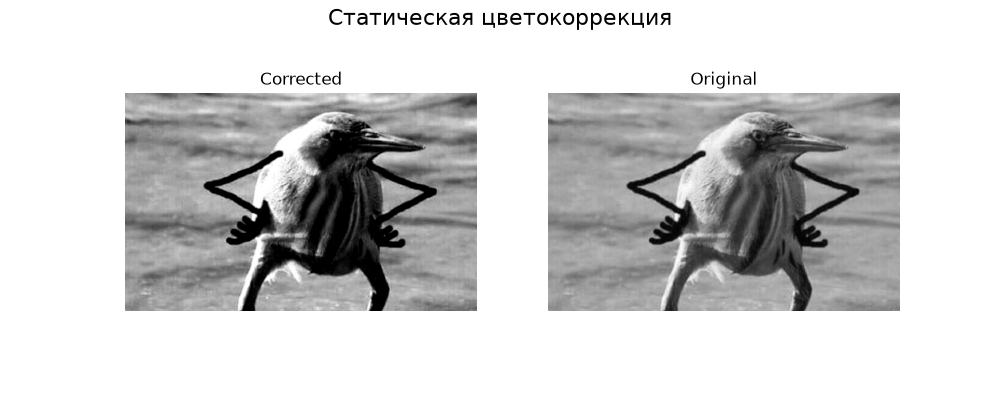

№6

In [ ]:
thresholds = [50, 100, 150, 200, 250]

img_u8 = img_gray.copy()

plt.figure(figsize=(10, 8))
plt.title('Пороговая фильтрация', fontsize=24)
plt.axis('off')

for i, t in enumerate(thresholds):
    _, thresh1 = cv2.threshold(img_gray, t, 255, cv2.THRESH_BINARY)
    plt.subplot(1,5,i+1)
    plt.title('Threshold {}'.format(t))
    plt.imshow(thresh1, cmap='gray')
    plt.axis('off')

plt.show()

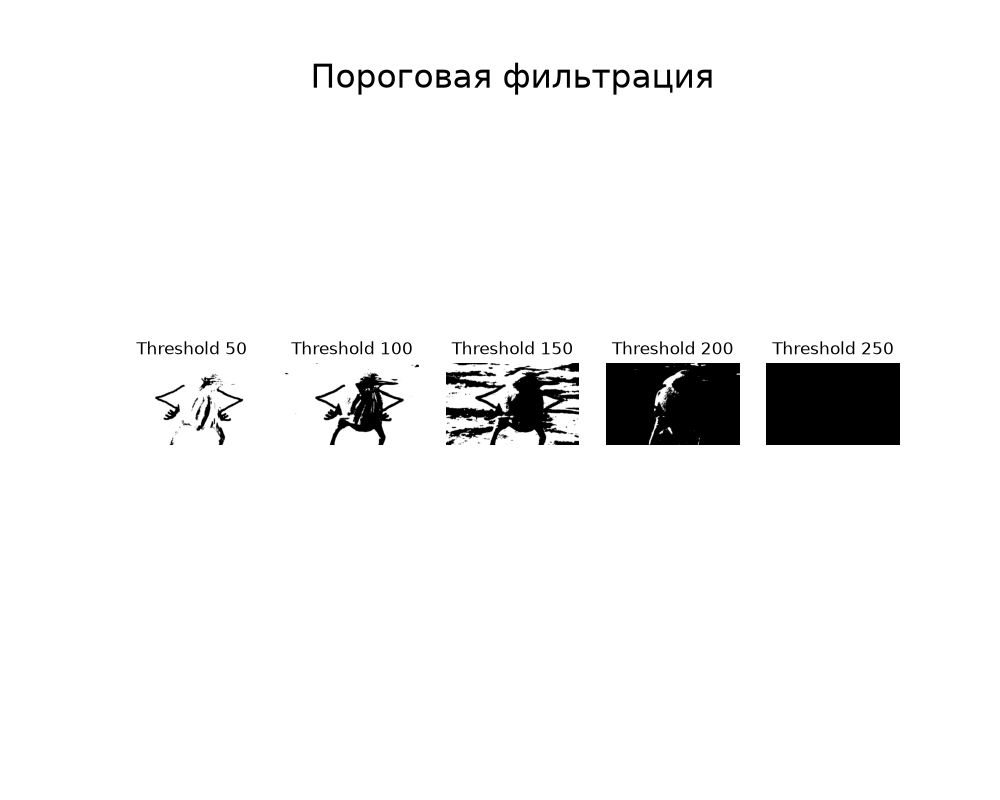